In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft
import pandas as pd
from scipy import signal
import seaborn as sns
sns.set()

# 8章演習問題

## (1) FIR

### (b) 振幅の大きさ

\begin{align*}
H(e^{j\omega} &= \frac{1}{4}(1 + 2e^{-j\omega} + e^{-2j\omega})\\
&= \frac{1}{4}(1 + e^{-j\omega})^2\\
&= \cos^2 \frac{\omega}{2} e^{-j\omega}\\
| H(e^{j\omega})| &= \frac{1+\cos \omega}{2}
\end{align*}

- 直流成分：２
- $\pm \frac{\pi}{4}$: $\frac{2+\sqrt{2}}{4}$
- $\pm \frac{\pi}{2}$: $\frac{1}{4}$
- $\pm \pi$: $0$

### (b) 入出力

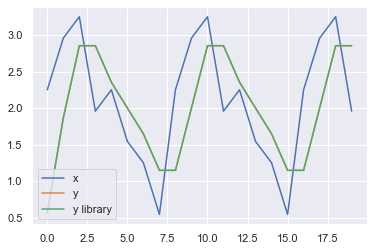

In [35]:
def generate_input(n):
    return 2.0 + np.sin(np.pi/4.0 * n) + 0.5 * np.sin(np.pi/2.0 * n) + 0.25 * np.cos(np.pi * n)

class MyFIR(object):
    def __init__(self, h):
        self.h = h
        self.buf = np.zeros_like(h)
        
    def partial_fit(self, x):
        self.buf = np.roll(self.buf, 1)
        self.buf[0] = x
        return np.dot(self.h, self.buf)
    
    def fit(self, xs):
        ys = np.zeros_like(xs)
        for i in range(xs.size):
            ys[i] = self.partial_fit(xs[i])
        return ys

h = np.array([1.0, 2.0, 1.0])/4.0
fir = MyFIR(h)
N = 20
xs = np.array([generate_input(n) for n in range(N)])
ys = fir.fit(xs)

ys2 = signal.lfilter(h, 1, xs)

plt.plot(range(N), xs, label="x")
plt.plot(range(N), ys, label="y")
plt.plot(range(N), ys2, label="y library")
plt.legend()

### (c) $h=\frac{1}{4}[1, -2, 1]$のとき

\begin{align*}
H(e^{j\omega}) &= \frac{1}{4}(1 - e^{-j\omega})^2\\
&= \sin^2\frac{\omega}{2}e^{-j\omega}\\
|H(e^{j\omega})| &= \sin^2\frac{\omega}{2}
\end{align*}

- 直流成分：0
- $\pm \frac{\pi}{4}$: $\frac{2-\sqrt{2}}{4}$
- $\pm \frac{\pi}{2}$: $\frac{1}{4}$
- $\pm \pi$: $\frac{1}{4}$

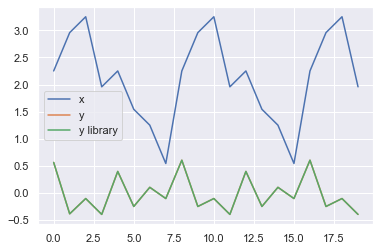

In [30]:
h = np.array([1.0, -2.0, 1.0])/4.0
fir = MyFIR(h)
N = 20
xs = np.array([generate_input(n) for n in range(N)])
ys = fir.fit(xs)

ys2 = signal.lfilter(h, 1, xs)

plt.plot(range(N), xs, label="x")
plt.plot(range(N), ys, label="y")
plt.plot(range(N), ys2, label="y library")
plt.legend()

## (2) 正規化周波数を用いた設計仕様

(a) $\frac{\pi}{2}$

(b) そのまま

(c) $\frac{3}{4}\pi$

(d) そのまま

## (3) ppt

## (4) 位相特性

### (a) $h(n)=\frac{1}{4}[1, \underline{2}, 1]$

\begin{align*}
H(e^{j\omega}) &= \cos^2\frac{\omega}{2}
\end{align*}

$\theta(\omega)=0$

$\tau_g(\omega)=0$

### (b) $h(n)=\frac{1}{4}[1, 2, 1]$


\begin{align*}
H(e^{j\omega}) &= \cos^2\frac{\omega}{2}e^{-j\omega}
\end{align*}

$\theta(\omega)=-\omega$

$\tau_g(\omega)=1$

### (c) $y(n) = \alpha y(n-1) + (1-\alpha)x(n)$

\begin{align*}
H(z) &= \frac{1 - \alpha}{1 - \alpha z^{-1}}\\
H(e^{j\omega}) &= \frac{1-\alpha+\alpha(\alpha-1)\cos\omega + j\alpha(\alpha-1)\sin\omega}
{1-\alpha^2-2\alpha\cos\omega}
\end{align*}


\begin{align*}
\theta(\omega) &= \tan^{-1}\left(\frac{\alpha}{\alpha-1}\tan{\omega}\right)\\
\tau_g(\omega) &= -\frac{\beta}{\cos^2\omega + \beta^2\sin^2\omega}\\
\end{align*}
ただし，$\beta=\frac{\alpha}{\alpha-1}$と置いた．

## (5)

## (6) 零位相特性

## 方法A

### (a) インパルス応答

順番逆になるけど，(b)の結果から$h_A(n) = h(n) * h(-n)$

### (b) 周波数応答

$(e^{j\omega})$は省略して書く

\begin{align*}
F &= HX\\
G &= HF^{*}\\
Y &= G^{*}=H^{*}HX=|H|^2X
\end{align*}

## 方法B

### (a) インパルス応答

$h_B(n) = h(n) + h(-n)$

### (b) 周波数応答

\begin{align*}
F &= HX\\
G &= HX^{*}\\
Y &= F + G^{*} = (H + H^{*})X = 2{\rm Re}(H)X
\end{align*}